In [1]:
import pandas as pd

data = {
    'job_title_short': ['Data Analyst', 'Data Scientist', 'Data Engineer'],
    'job_skills': [['excel', 'sql', 'python'], ['python', 'r'], ['aws', 'python', 'airflow']]
}

df_skill_lists = pd.DataFrame(data)

df_skill_lists

,job_title_short,job_skills
0,Data Analyst,"[excel, sql, python]"
1,Data Scientist,"[python, r]"
2,Data Engineer,"[aws, python, airflow]"


Without Explode Method
---------------------------

In [2]:
all_skills = set()

for skills in df_skill_lists['job_skills']:
    all_skills.update(skills)

all_skills=sorted(list(all_skills))

for skill in all_skills:
    df_skill_lists[skill]=df_skill_lists['job_skills'].apply(lambda skills: 1 if skill in skills else 0)


df_skill_lists['total_skills'] = df_skill_lists[all_skills].sum(axis=1)
df_skill_lists

,job_title_short,job_skills,airflow,aws,excel,python,r,sql,total_skills
0,Data Analyst,"[excel, sql, python]",0,0,1,1,0,1,3
1,Data Scientist,"[python, r]",0,0,0,1,1,0,2
2,Data Engineer,"[aws, python, airflow]",1,1,0,1,0,0,3


With Explode Method
-----------------------

In [3]:
df_new=df_skill_lists.explode('job_skills').reset_index(drop=True).copy()
df_new

,job_title_short,job_skills,airflow,aws,excel,python,r,sql,total_skills
0,Data Analyst,excel,0,0,1,1,0,1,3
1,Data Analyst,sql,0,0,1,1,0,1,3
2,Data Analyst,python,0,0,1,1,0,1,3
3,Data Scientist,python,0,0,0,1,1,0,2
4,Data Scientist,r,0,0,0,1,1,0,2
5,Data Engineer,aws,1,1,0,1,0,0,3
6,Data Engineer,python,1,1,0,1,0,0,3
7,Data Engineer,airflow,1,1,0,1,0,0,3


Example on the Dataset
--------------------

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
import ast
# Load the dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Data Cleaning
df["job_posted_date"]=pd.to_datetime(df["job_posted_date"])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else x)
df_exploded= df.explode('job_skills')


pandas.DataFrame

In [23]:
type(df_exploded)


pandas.DataFrame

<Axes: xlabel='job_skills'>

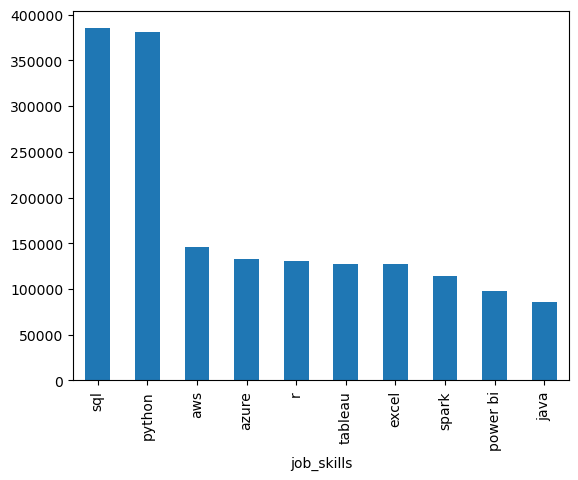

In [9]:
df_exploded.value_counts('job_skills').head(10).plot(kind='bar')

In [36]:
skills_count=df_exploded.groupby([ 'job_title_short','job_skills']).size()


top_5_jobs = df_exploded['job_title_short'].value_counts().head(5).index.tolist()
top_5_jobs


['Data Engineer',
 'Data Scientist',
 'Data Analyst',
 'Senior Data Engineer',
 'Software Engineer']

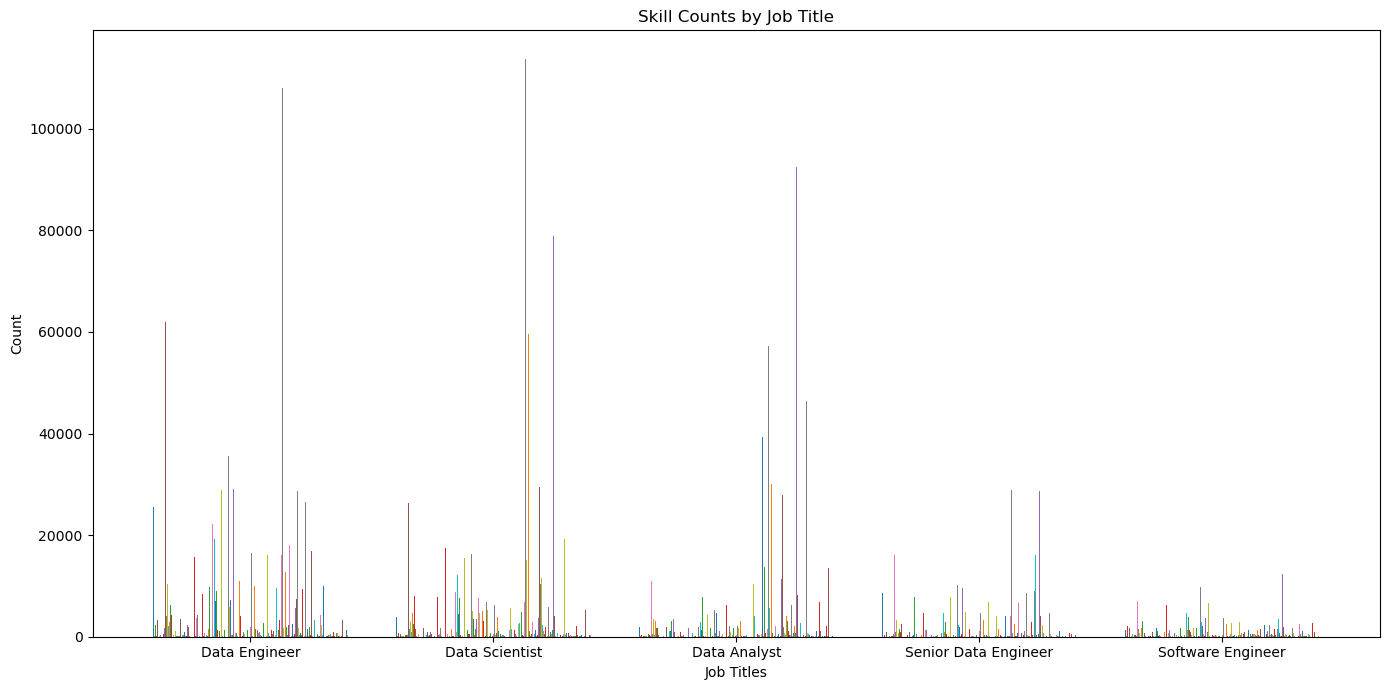

In [ ]:
'''

/*** The following code will create a bar plot showing the count of each skill for the top 5 job titles.
# 1. Reset your aggregated Series to a clean DataFrame
skills_df = skills_count.reset_index(name='count')

# 2. Filter using your list of top 5 jobs
filtered_df = skills_df[skills_df['job_title_short'].isin(top_5_jobs)]

pivot_df = filtered_df.pivot(index='job_title_short', columns='job_skills', values='count').fillna(0)

# 3. Reorder rows to match your top 5 list
pivot_df = pivot_df.loc[top_5_jobs]

# 4. Plot directly from the DataFrame
ax = pivot_df.plot(kind='bar', figsize=(14, 7), width=0.8, legend=False)

# 5. Labels and cleanup
plt.title('Skill Counts by Job Title')
plt.xlabel('Job Titles')
plt.ylabel('Count')
plt.xticks(rotation=0)  # Keeps job titles horizontal and easy to read
plt.tight_layout()
plt.show()
***/

'''

In [47]:
# 1. Reset your aggregated Series to a clean DataFrame
skills_df = skills_count.reset_index(name='count')

skills_df= skills_df.sort_values(by='count', ascending=False)

skills_df

,job_title_short,job_skills,count
1066,Data Scientist,python,113711
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
625,Data Analyst,sql,92428
1101,Data Scientist,sql,78982
...,...,...,...
462,Data Analyst,chainer,1
432,Cloud Engineer,wrike,1
410,Cloud Engineer,theano,1
24,Business Analyst,chainer,1


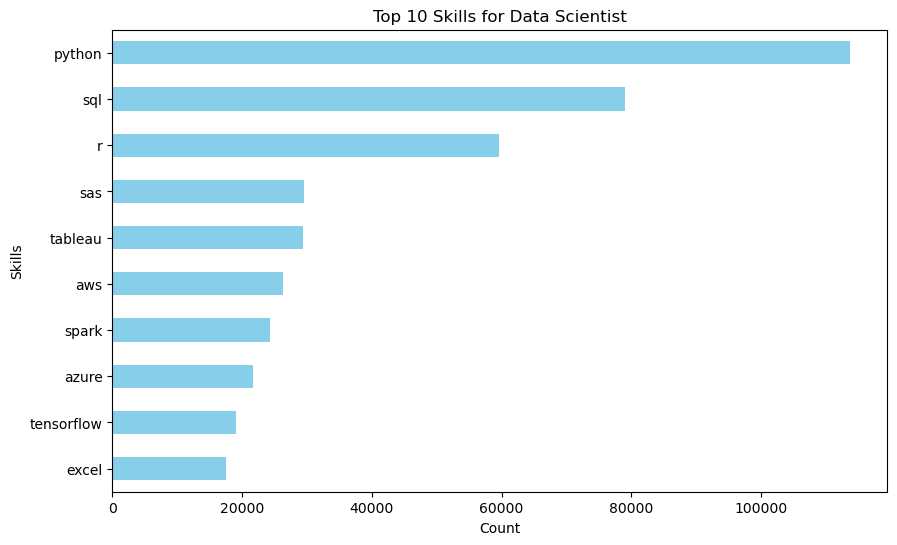

In [69]:
job_title='Data Scientist'
top_skills=10

# 1. Filter for the job title
job_df = skills_df[skills_df['job_title_short'] == job_title]

# 2. SORT FIRST, then take the top 10 rows
filtered_df = job_df.sort_values(by='count', ascending=False).head(top_skills)

filtered_df.plot(kind='barh', x='job_skills', y='count', legend=False, figsize=(10, 6), color='skyblue')
plt.title(f'Top {top_skills} Skills for {job_title}')
plt.xlabel('Count')
plt.ylabel('Skills')
plt.legend().set_visible(False)
plt.gca().invert_yaxis()  # Invert y-axis to have the highest count on top
plt.show()